In [1]:
import pandas as pd

In [2]:
you = pd.read_csv('youtube_county_mentioned_token_df.csv')
red = pd.read_csv('reddit_county_mentioned_token_df.csv')

In [3]:
you.columns

Index(['year', 'video_id', 'comment_tokens', 'reply_tokens',
       'comment_countries', 'reply_countries'],
      dtype='object')

In [4]:
red.columns

Index(['year', 'post_id', 'submission_tokens', 'comment_tokens',
       'submission_countries', 'comment_countries'],
      dtype='object')

In [5]:
import pandas as pd

youtube=you
reddit=red

# Rename columns to unify
youtube_renamed = youtube.rename(columns={
    'video_id': 'post_id',
    'comment_tokens': 'submission_tokens',
    'reply_tokens': 'comment_tokens',
    'comment_countries': 'submission_countries',
    'reply_countries': 'comment_countries'
})

# Add platform indicator
youtube_renamed['platform'] = 'YouTube'
reddit['platform'] = 'Reddit'

# Concatenate datasets
combined = pd.concat([youtube_renamed, reddit], ignore_index=True)

# Preview combined data
combined.head()


,year,post_id,submission_tokens,comment_tokens,submission_countries,comment_countries,platform
0,2025,40W27HZCcso,"['amaz', 'content', 'im', 'go', 'bali', 'year'...","['absolut', 'hope', 'great', 'trip', 'thank', ...","['Japan', 'Indonesia', 'Singapore']",[],YouTube
1,2025,40W27HZCcso,"['amaz', 'content', 'im', 'go', 'bali', 'year'...","['tri', 'get', 'travel', 'guid', 'go', 'wish',...","['Japan', 'Indonesia', 'Singapore']",[],YouTube
2,2025,40W27HZCcso,"['video', 'stun', 'watch', 'anyon', 'feel', 'l...",[],[],[],YouTube
3,2025,40W27HZCcso,"['im', 'plan', 'visit', 'georgiamalaysiaturkey...","['that', 'go', 'amaz', 'trip']","['Malaysia', 'Japan', 'Turkey', 'Georgia']",[],YouTube
4,2025,40W27HZCcso,"['happi', 'new', 'year', 'gonna', 'sick']","['cant', 'wait', 'see', 'get']",[],[],YouTube


In [6]:
# overview

import numpy as np
combined = combined.replace('[]', np.nan)
combined.isnull().sum()

year                       0
post_id                    0
submission_tokens        792
comment_tokens          2165
submission_countries    2059
comment_countries       3410
platform                   0
dtype: int64

In [7]:
combined

,year,post_id,submission_tokens,comment_tokens,submission_countries,comment_countries,platform
0,2025,40W27HZCcso,"['amaz', 'content', 'im', 'go', 'bali', 'year'...","['absolut', 'hope', 'great', 'trip', 'thank', ...","['Japan', 'Indonesia', 'Singapore']",NaN,YouTube
1,2025,40W27HZCcso,"['amaz', 'content', 'im', 'go', 'bali', 'year'...","['tri', 'get', 'travel', 'guid', 'go', 'wish',...","['Japan', 'Indonesia', 'Singapore']",NaN,YouTube
2,2025,40W27HZCcso,"['video', 'stun', 'watch', 'anyon', 'feel', 'l...",NaN,NaN,NaN,YouTube
3,2025,40W27HZCcso,"['im', 'plan', 'visit', 'georgiamalaysiaturkey...","['that', 'go', 'amaz', 'trip']","['Malaysia', 'Japan', 'Turkey', 'Georgia']",NaN,YouTube
4,2025,40W27HZCcso,"['happi', 'new', 'year', 'gonna', 'sick']","['cant', 'wait', 'see', 'get']",NaN,NaN,YouTube
...,...,...,...,...,...,...,...
5472,2018,aap3jo,"['updat', 'loser', 'whose', 'girlfriend', 'ric...","['dude', 'that', 'wonder', 'hear', 'realli', '...","['Mexico', 'United States']","['Russian Federation', 'Turkey', 'Mexico', 'Fr...",Reddit
5473,2024,1b3m114,"['new', 'updat', 'aitah', 'cancel', 'wed', 'oo...","['comment', 'origin', 'post', 'pleas', 'read',...","['Chile', 'United States']","['Thailand', 'Brazil', 'Chile', 'Spain', 'Pola...",Reddit
5474,2021,ql8klq,"['aita', 'call', 'sister', 'fuck', 'stupid', '...","['obviou', 'nta', 'took', 'offer', 'fact', 'do...",['United States'],"['Canada', 'Turkey', 'France', 'United Kingdom...",Reddit
5475,2024,1f6qm8k,"['im', 'australian', 'post', 'around', 'nine',...","['fun', 'that', 'main', 'object', 'nice', 'bal...","['France', 'United States', 'United Kingdom']","['Canada', 'France', 'United Kingdom', 'Austra...",Reddit


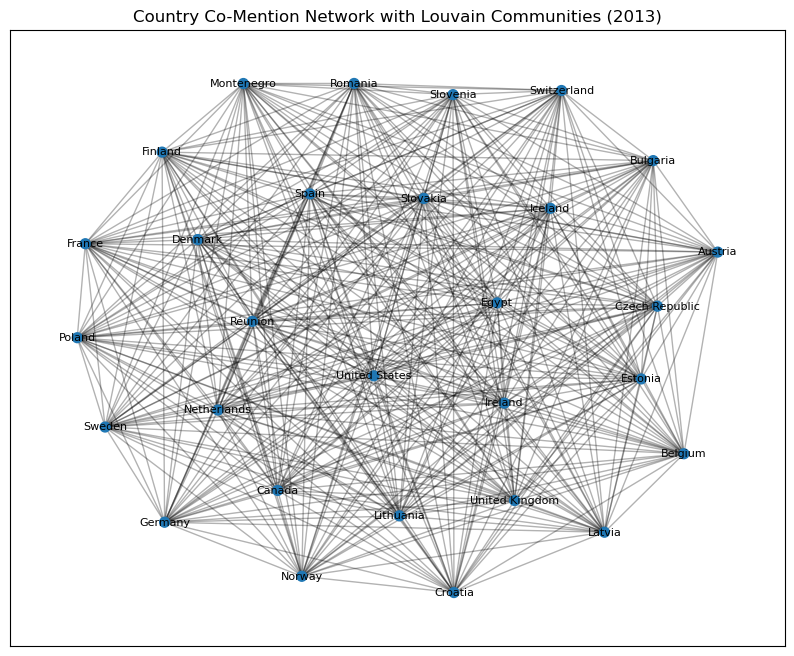

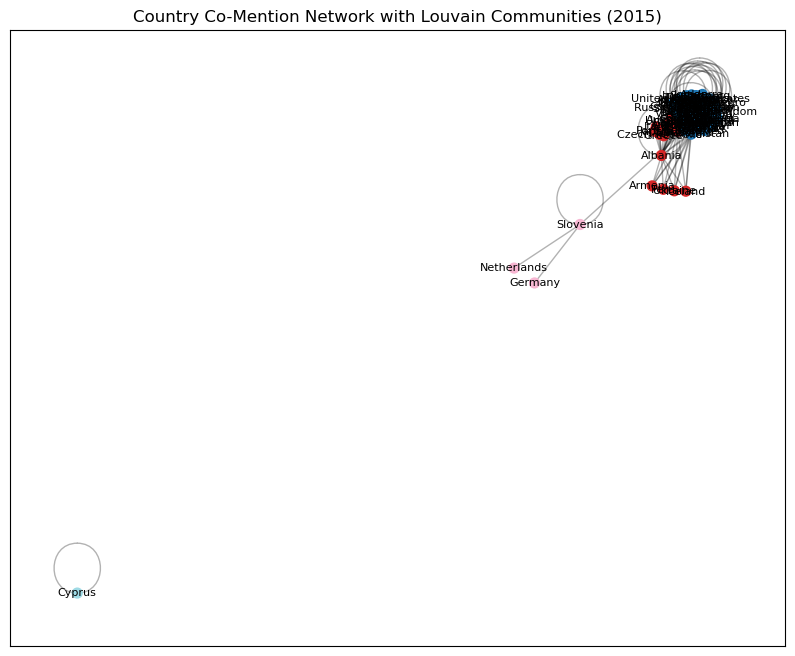

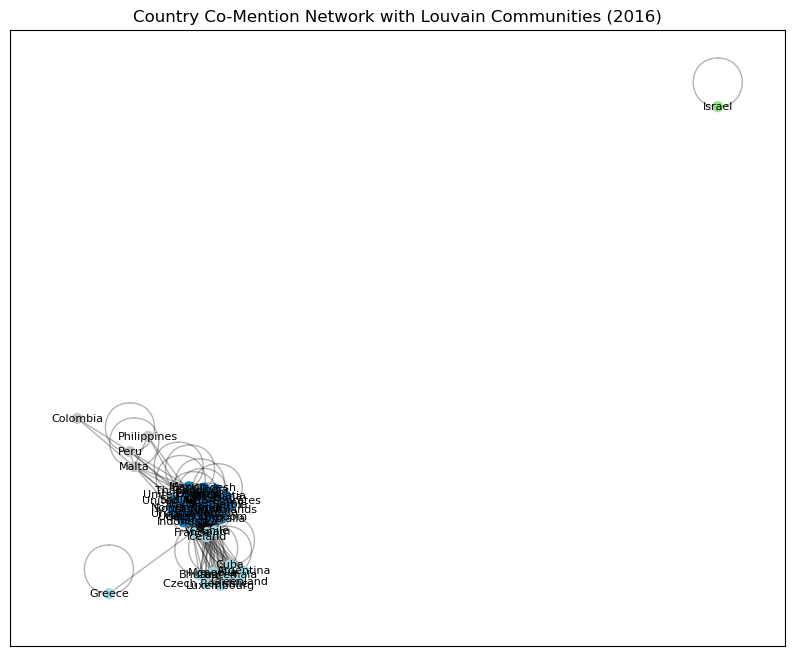

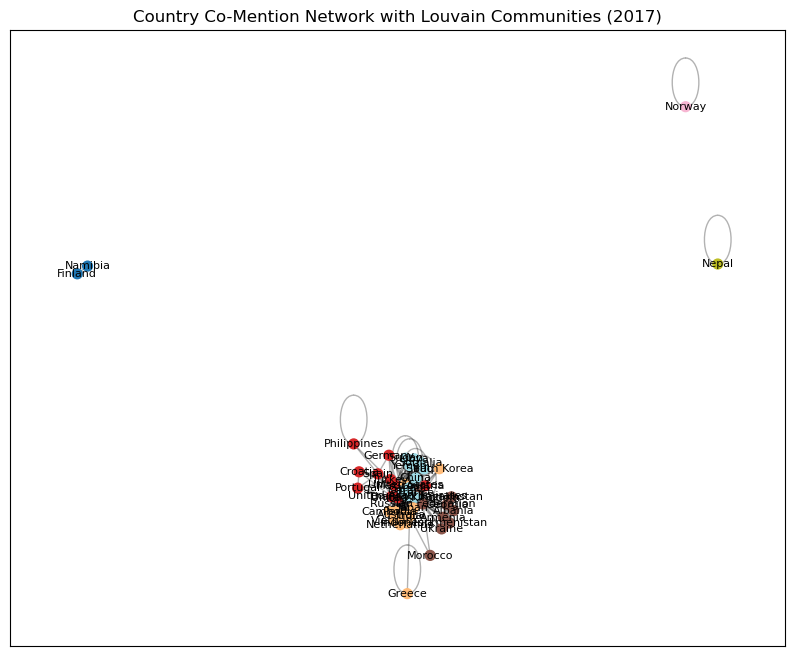

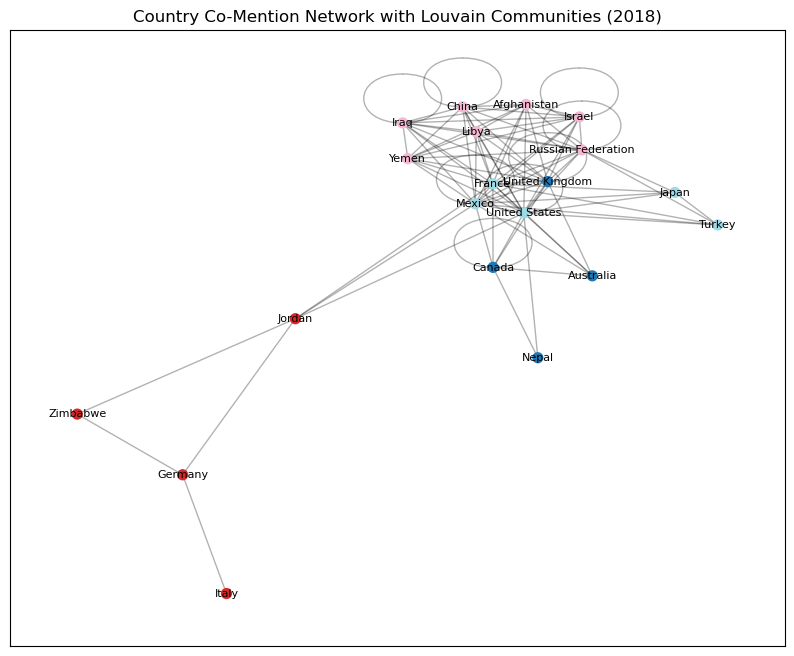

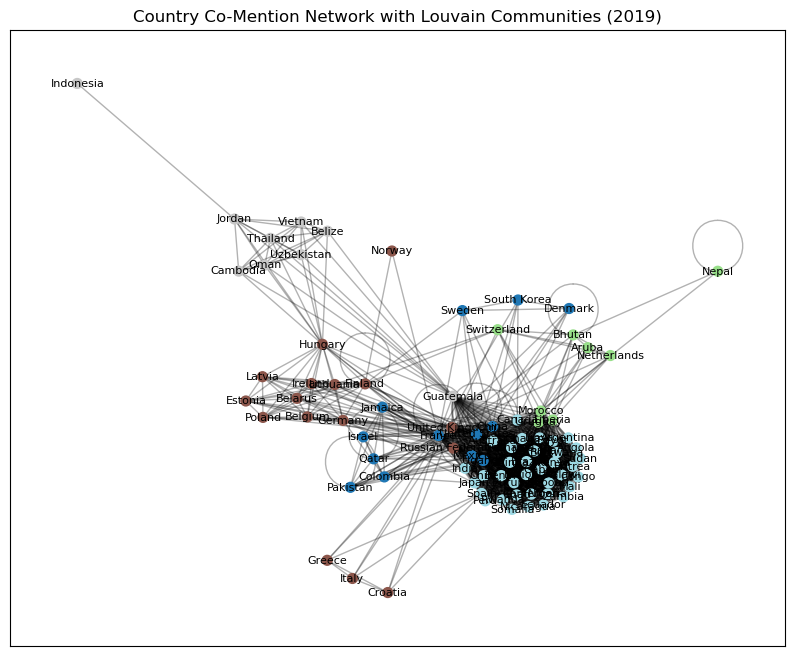

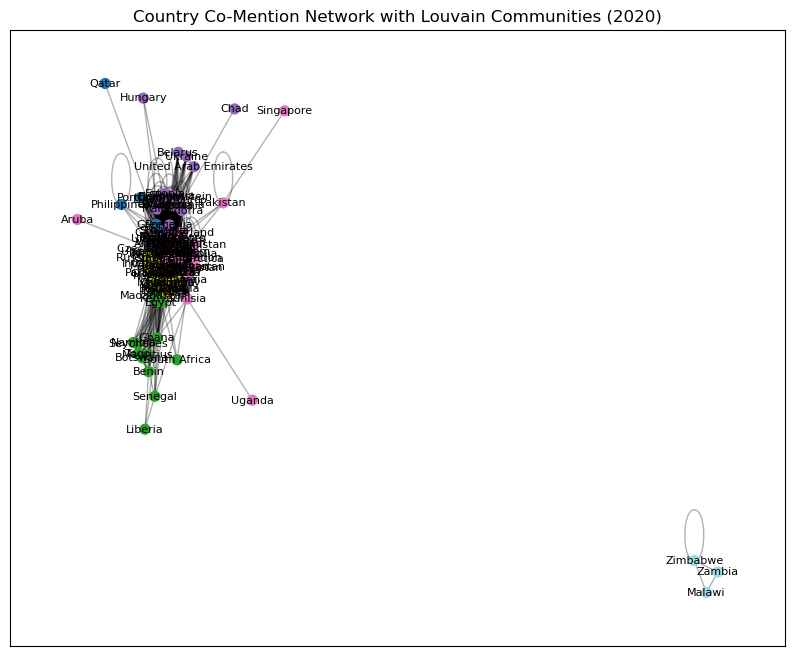

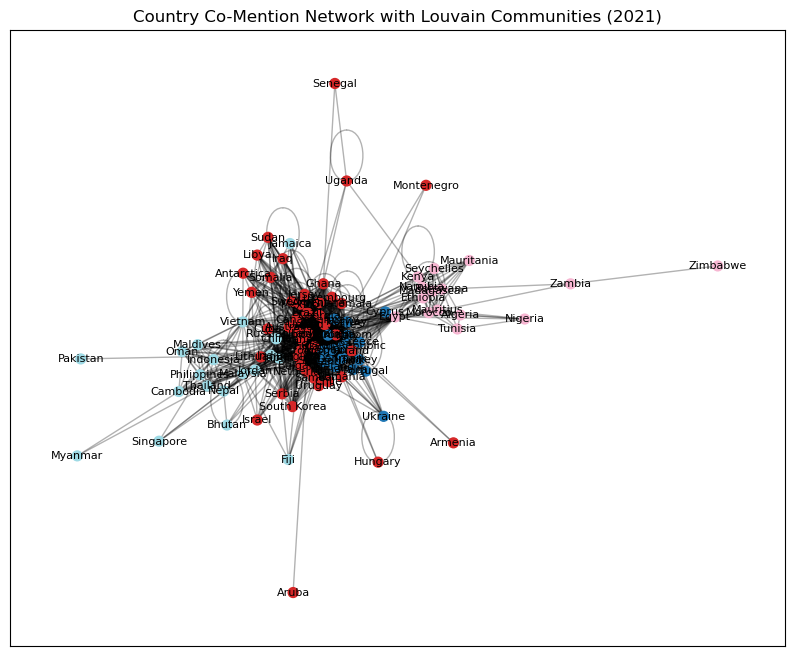

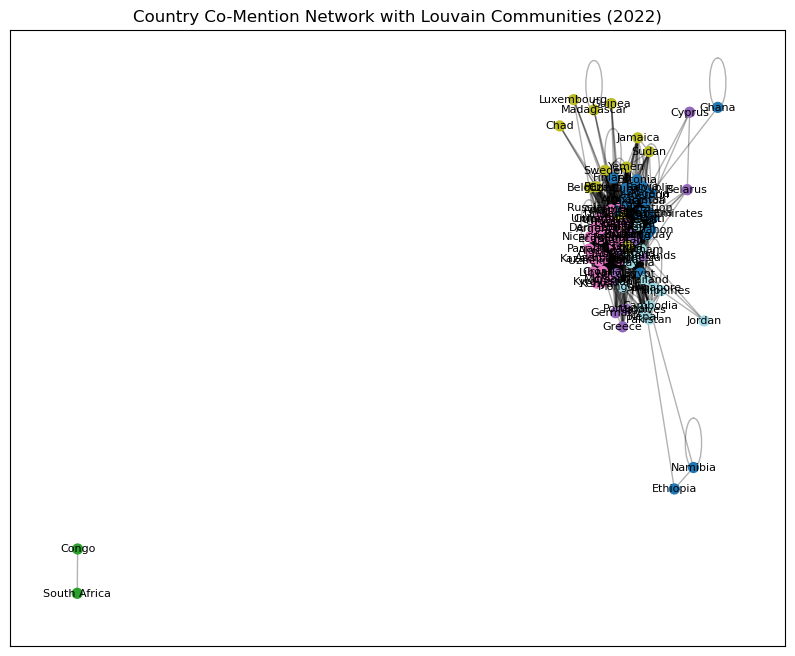

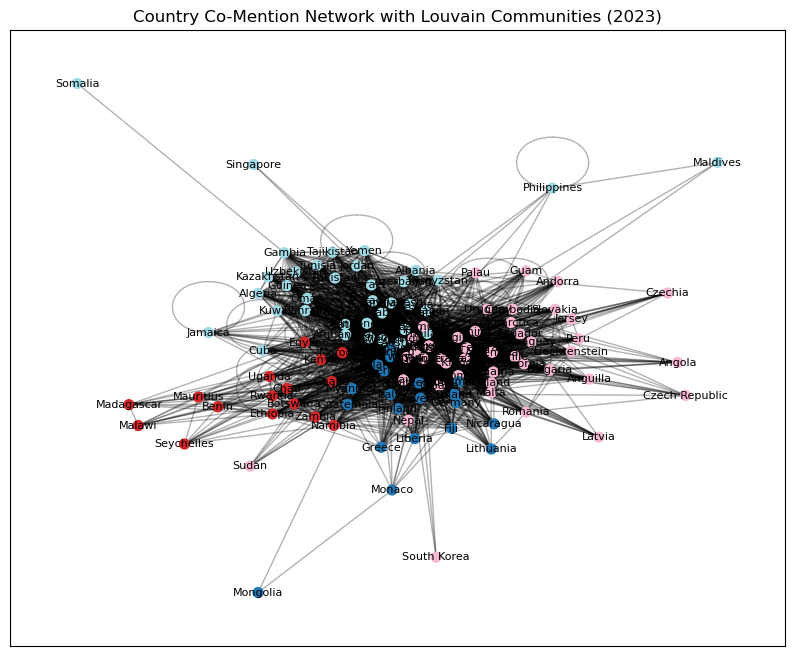

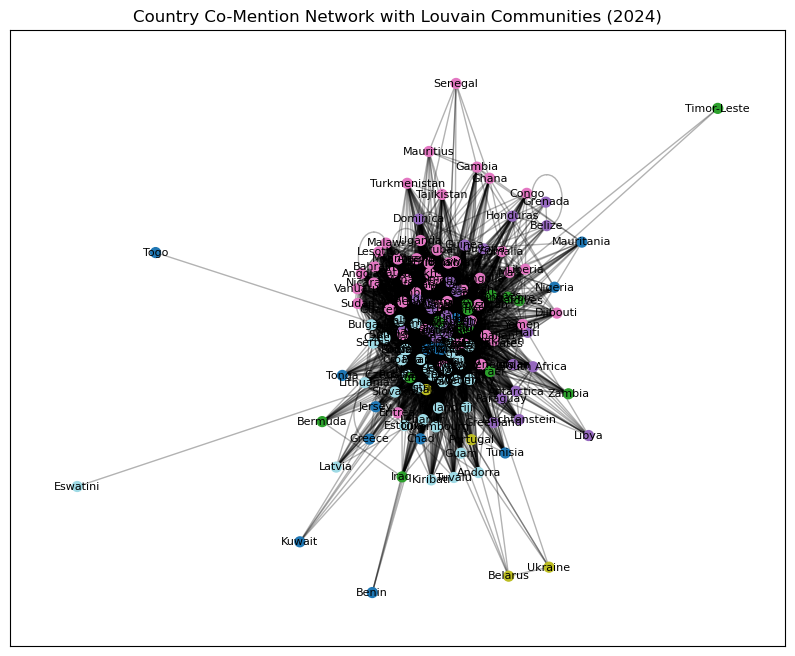

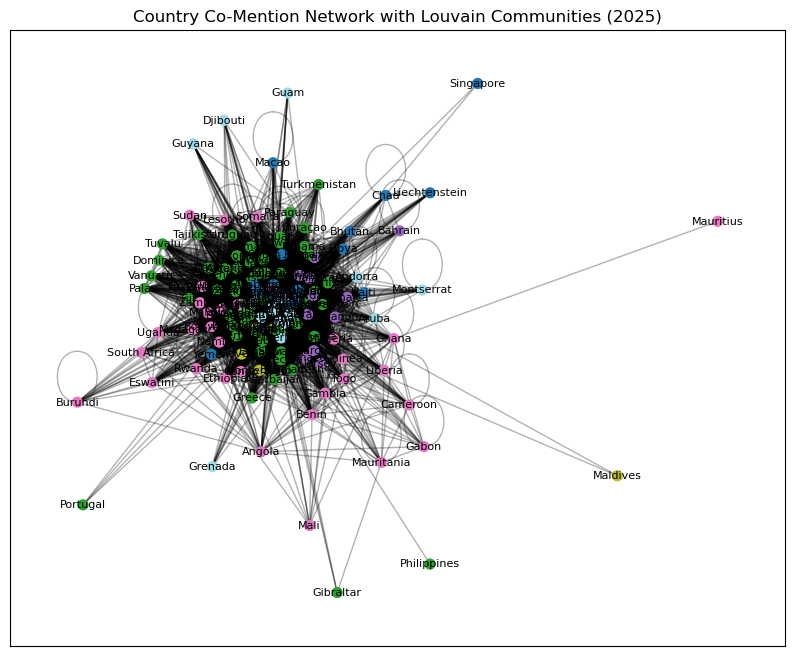

In [8]:
import pandas as pd
import networkx as nx
from collections import Counter
from community import community_louvain  # Louvain detection package
import matplotlib.pyplot as plt

# Combine all country mentions per row
def extract_country_pairs(row):
    countries = []
    for col in ['submission_countries', 'comment_countries']:
        if pd.notnull(row[col]):
            countries.extend(row[col].strip('[]').replace("'", "").split(','))
    countries = [c.strip() for c in countries if c.strip()]
    return [(c1, c2) for i, c1 in enumerate(countries) for c2 in countries[i+1:]]

# Create co-mention pairs with year
combined['country_pairs'] = combined.apply(extract_country_pairs, axis=1)

# Flatten and count co-mention pairs per year
pairs_per_year = {}
for year, group in combined.groupby('year'):
    pairs = [pair for sublist in group['country_pairs'] for pair in sublist]
    pair_counts = Counter(pairs)
    pairs_per_year[year] = pair_counts

# Build and analyze network per year
for year, counts in pairs_per_year.items():
    G = nx.Graph()
    for (c1, c2), weight in counts.items():
        G.add_edge(c1, c2, weight=weight)
    
    # Louvain community detection
    partition = community_louvain.best_partition(G, weight='weight')
    
    # Visualize network with communities
    pos = nx.spring_layout(G)
    plt.figure(figsize=(10, 8))
    cmap = plt.get_cmap('tab20')
    nx.draw_networkx_nodes(G, pos, node_size=50, node_color=[partition[n] for n in G.nodes()], cmap=cmap)
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(f"Country Co-Mention Network with Louvain Communities ({year})")
    plt.show()
    
    # Optional: Summarize community cohesion here


In [9]:
import pandas as pd
import networkx as nx
from collections import Counter
from community import community_louvain  # Louvain detection package
import matplotlib.pyplot as plt
import os

# Combine all country mentions per row
def extract_country_pairs(row):
    countries = []
    for col in ['submission_countries', 'comment_countries']:
        if pd.notnull(row[col]):
            countries.extend(row[col].strip('[]').replace("'", "").split(','))
    countries = [c.strip() for c in countries if c.strip()]
    return [(c1, c2) for i, c1 in enumerate(countries) for c2 in countries[i+1:]]

# Create co-mention pairs with year
combined['country_pairs'] = combined.apply(extract_country_pairs, axis=1)

# Flatten and count co-mention pairs per year
pairs_per_year = {}
for year, group in combined.groupby('year'):
    pairs = [pair for sublist in group['country_pairs'] for pair in sublist]
    pair_counts = Counter(pairs)
    pairs_per_year[year] = pair_counts

# Create folder for GEXF files
os.makedirs('gexf_networks', exist_ok=True)

for year, counts in pairs_per_year.items():
    G = nx.Graph()
    for (c1, c2), weight in counts.items():
        G.add_edge(c1, c2, weight=weight)
    
    # Add Louvain community detection as node attribute
    partition = community_louvain.best_partition(G, weight='weight')
    nx.set_node_attributes(G, partition, 'community')
    
    # Add degree (number of connections) as node attribute
    degree_dict = dict(G.degree())
    nx.set_node_attributes(G, degree_dict, 'degree')
    
    # Optional: Add total weight of edges connected to each node (strength)
    strength_dict = {node: sum(d['weight'] for _, _, d in G.edges(node, data=True)) for node in G.nodes()}
    nx.set_node_attributes(G, strength_dict, 'strength')
    
    # Save GEXF file with attributes for Gephi
    gexf_filename = f'gexf_networks/country_co_mention_{year}.gexf'
    nx.write_gexf(G, gexf_filename)
    print(f"Saved GEXF with attributes for year {year}: {gexf_filename}")


Saved GEXF with attributes for year 2013: gexf_networks/country_co_mention_2013.gexf
Saved GEXF with attributes for year 2015: gexf_networks/country_co_mention_2015.gexf
Saved GEXF with attributes for year 2016: gexf_networks/country_co_mention_2016.gexf
Saved GEXF with attributes for year 2017: gexf_networks/country_co_mention_2017.gexf
Saved GEXF with attributes for year 2018: gexf_networks/country_co_mention_2018.gexf
Saved GEXF with attributes for year 2019: gexf_networks/country_co_mention_2019.gexf
Saved GEXF with attributes for year 2020: gexf_networks/country_co_mention_2020.gexf
Saved GEXF with attributes for year 2021: gexf_networks/country_co_mention_2021.gexf
Saved GEXF with attributes for year 2022: gexf_networks/country_co_mention_2022.gexf
Saved GEXF with attributes for year 2023: gexf_networks/country_co_mention_2023.gexf
Saved GEXF with attributes for year 2024: gexf_networks/country_co_mention_2024.gexf
Saved GEXF with attributes for year 2025: gexf_networks/country_c

In [10]:
combined

,year,post_id,submission_tokens,comment_tokens,submission_countries,comment_countries,platform,country_pairs
0,2025,40W27HZCcso,"['amaz', 'content', 'im', 'go', 'bali', 'year'...","['absolut', 'hope', 'great', 'trip', 'thank', ...","['Japan', 'Indonesia', 'Singapore']",NaN,YouTube,"[(Japan, Indonesia), (Japan, Singapore), (Indo..."
1,2025,40W27HZCcso,"['amaz', 'content', 'im', 'go', 'bali', 'year'...","['tri', 'get', 'travel', 'guid', 'go', 'wish',...","['Japan', 'Indonesia', 'Singapore']",NaN,YouTube,"[(Japan, Indonesia), (Japan, Singapore), (Indo..."
2,2025,40W27HZCcso,"['video', 'stun', 'watch', 'anyon', 'feel', 'l...",NaN,NaN,NaN,YouTube,[]
3,2025,40W27HZCcso,"['im', 'plan', 'visit', 'georgiamalaysiaturkey...","['that', 'go', 'amaz', 'trip']","['Malaysia', 'Japan', 'Turkey', 'Georgia']",NaN,YouTube,"[(Malaysia, Japan), (Malaysia, Turkey), (Malay..."
4,2025,40W27HZCcso,"['happi', 'new', 'year', 'gonna', 'sick']","['cant', 'wait', 'see', 'get']",NaN,NaN,YouTube,[]
...,...,...,...,...,...,...,...,...
5472,2018,aap3jo,"['updat', 'loser', 'whose', 'girlfriend', 'ric...","['dude', 'that', 'wonder', 'hear', 'realli', '...","['Mexico', 'United States']","['Russian Federation', 'Turkey', 'Mexico', 'Fr...",Reddit,"[(Mexico, United States), (Mexico, Russian Fed..."
5473,2024,1b3m114,"['new', 'updat', 'aitah', 'cancel', 'wed', 'oo...","['comment', 'origin', 'post', 'pleas', 'read',...","['Chile', 'United States']","['Thailand', 'Brazil', 'Chile', 'Spain', 'Pola...",Reddit,"[(Chile, United States), (Chile, Thailand), (C..."
5474,2021,ql8klq,"['aita', 'call', 'sister', 'fuck', 'stupid', '...","['obviou', 'nta', 'took', 'offer', 'fact', 'do...",['United States'],"['Canada', 'Turkey', 'France', 'United Kingdom...",Reddit,"[(United States, Canada), (United States, Turk..."
5475,2024,1f6qm8k,"['im', 'australian', 'post', 'around', 'nine',...","['fun', 'that', 'main', 'object', 'nice', 'bal...","['France', 'United States', 'United Kingdom']","['Canada', 'France', 'United Kingdom', 'Austra...",Reddit,"[(France, United States), (France, United King..."


In [11]:
import pandas as pd
import networkx as nx
from collections import Counter
from community import community_louvain

# 1️⃣ 지역/문화 그룹 딕셔너리 정의
region_groups = {
    'ASEAN': {'Indonesia', 'Malaysia', 'Singapore', 'Thailand', 'Vietnam', 'Philippines', 'Brunei', 'Myanmar', 'Cambodia', 'Laos'},
    'EU': {'France', 'Germany', 'Italy', 'Spain', 'Netherlands', 'Belgium', 'Poland', 'Sweden', 'Denmark', 'Finland'},
    'North_America': {'USA', 'Canada', 'Mexico'},
    'East_Asia': {'China', 'Japan', 'South Korea', 'Taiwan', 'Hong Kong'},
    # 필요시 추가
}

# 2️⃣ 데이터셋 (combined) 준비 (이미 로드되어 있다고 가정)
# combined = pd.read_csv('combined_data.csv')

# 3️⃣ year별 country_pairs 추출 및 카운트
pairs_per_year = {}
for year, group in combined.groupby('year'):
    all_pairs = [pair for pairs_list in group['country_pairs'] if pairs_list for pair in pairs_list]
    pair_counts = Counter(all_pairs)
    pairs_per_year[year] = pair_counts

# 4️⃣ Louvain 커뮤니티 탐지 및 지역 그룹 매칭
for year, counts in pairs_per_year.items():
    G = nx.Graph()
    for (c1, c2), weight in counts.items():
        G.add_edge(c1, c2, weight=weight)
    
    partition = community_louvain.best_partition(G, weight='weight')
    
    # 커뮤니티별 국가 리스트
    community_groups = {}
    for node, comm_id in partition.items():
        community_groups.setdefault(comm_id, set()).add(node)
    
    print(f"\n=== Year: {year} ===")
    for comm_id, countries in community_groups.items():
        print(f"Community {comm_id}: {countries}")

        # 지역 그룹 매칭 평가
        for region, region_countries in region_groups.items():
            matched = countries & region_countries
            if matched:
                precision = len(matched) / len(countries)
                recall = len(matched) / len(region_countries)
                f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
                print(f"  ↳ Region: {region}")
                print(f"    Matched Countries: {matched}")
                print(f"    Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")



=== Year: 2013 ===
Community 0: {'Canada', 'Netherlands', 'Bulgaria', 'United Kingdom', 'Germany', 'Ireland', 'France', 'Poland', 'Slovakia', 'Czech Republic', 'Spain', 'Switzerland', 'Slovenia', 'Sweden', 'Finland', 'Latvia', 'Egypt', 'Estonia', 'Lithuania', 'Romania', 'United States', 'Denmark', 'Croatia', 'Réunion', 'Austria', 'Montenegro', 'Belgium', 'Norway', 'Iceland'}
  ↳ Region: EU
    Matched Countries: {'Netherlands', 'Finland', 'France', 'Poland', 'Denmark', 'Spain', 'Belgium', 'Germany', 'Sweden'}
    Precision: 0.31, Recall: 0.90, F1: 0.46
  ↳ Region: North_America
    Matched Countries: {'Canada'}
    Precision: 0.03, Recall: 0.33, F1: 0.06

=== Year: 2015 ===
Community 0: {'Congo', 'Lebanon', 'Malawi', 'Oman', 'Kiribati', 'Eritrea', 'Guinea', 'Sudan', 'Rwanda', 'Afghanistan', 'Chad', 'Somalia', 'United Kingdom', 'Bahrain', 'Algeria', 'Uzbekistan', 'Israel', 'Russian Federation', 'Ireland', 'Cuba', 'France', 'Jordan', 'Botswana', 'Libya', 'Kuwait', 'Zambia', 'Morocco', '

    Year  Community         Region  NumCountries  MatchedCountries  Precision  \
0   2013          0             EU            29                 9   0.310345   
1   2013          0  North_America            29                 1   0.034483   
2   2015          0          ASEAN            69                 1   0.014493   
3   2015          0             EU            69                 5   0.072464   
4   2015          0  North_America            69                 1   0.014493   
..   ...        ...            ...           ...               ...        ...   
86  2025          5             EU            17                 5   0.294118   
87  2025          5  North_America            17                 1   0.058824   
88  2025          2          ASEAN            11                 2   0.181818   
89  2025          2             EU            11                 1   0.090909   
90  2025          2  North_America            11                 1   0.090909   

      Recall        F1  
0 

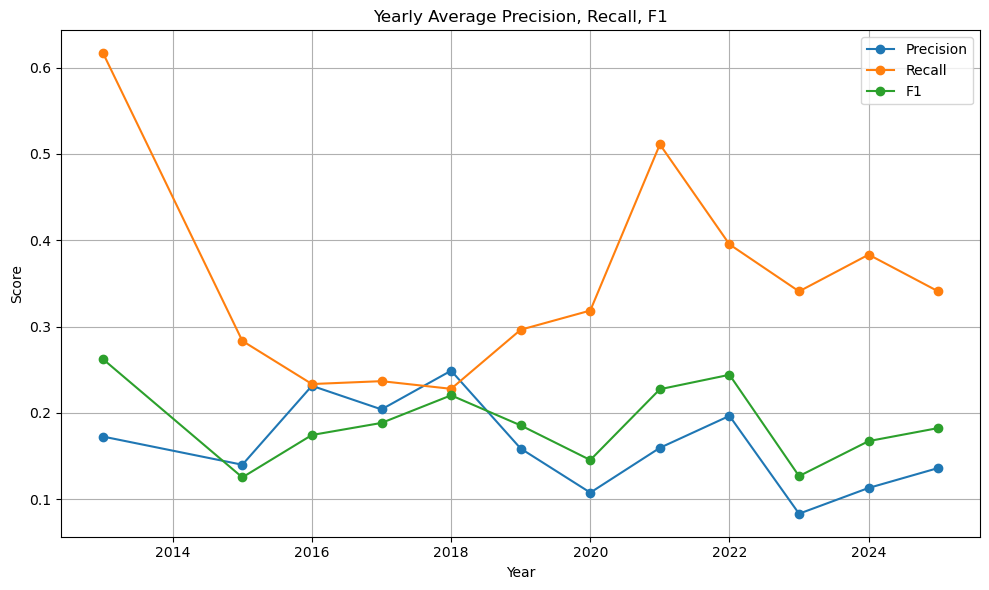

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 결과 저장용 리스트
results = []

# 기존 루프를 수정하여 결과를 저장
for year, counts in pairs_per_year.items():
    G = nx.Graph()
    for (c1, c2), weight in counts.items():
        G.add_edge(c1, c2, weight=weight)
    partition = community_louvain.best_partition(G, weight='weight')
    
    community_groups = {}
    for node, comm_id in partition.items():
        community_groups.setdefault(comm_id, set()).add(node)
    
    for comm_id, countries in community_groups.items():
        for region, region_countries in region_groups.items():
            matched = countries & region_countries
            if matched:
                precision = len(matched) / len(countries)
                recall = len(matched) / len(region_countries)
                f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
                results.append({
                    'Year': year,
                    'Community': comm_id,
                    'Region': region,
                    'NumCountries': len(countries),
                    'MatchedCountries': len(matched),
                    'Precision': precision,
                    'Recall': recall,
                    'F1': f1
                })

# DataFrame으로 정리
results_df = pd.DataFrame(results)
print(results_df)

# 📈 연도별 평균 Precision, Recall, F1 시각화
avg_per_year = results_df.groupby('Year')[['Precision', 'Recall', 'F1']].mean().reset_index()
plt.figure(figsize=(10,6))
plt.plot(avg_per_year['Year'], avg_per_year['Precision'], marker='o', label='Precision')
plt.plot(avg_per_year['Year'], avg_per_year['Recall'], marker='o', label='Recall')
plt.plot(avg_per_year['Year'], avg_per_year['F1'], marker='o', label='F1')
plt.xlabel('Year')
plt.ylabel('Score')
plt.title('Yearly Average Precision, Recall, F1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('yearly_avg_metrics.png', dpi=300)
plt.show()


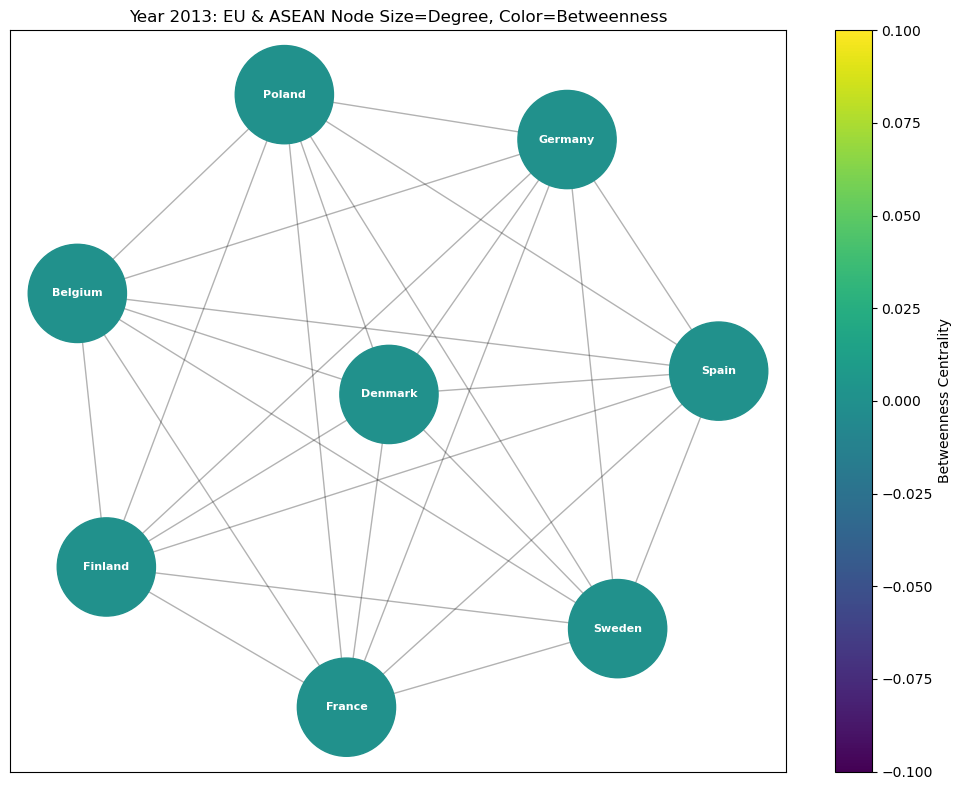


=== Year: 2013 ===
Top Degree Centrality:
   Year  Country  DegreeCentrality  BetweennessCentrality
0  2013  Germany               1.0                    0.0
1  2013    Spain               1.0                    0.0
2  2013  Finland               1.0                    0.0
3  2013  Belgium               1.0                    0.0
4  2013  Denmark               1.0                    0.0
Top Betweenness Centrality:
   Year  Country  DegreeCentrality  BetweennessCentrality
0  2013  Germany               1.0                    0.0
1  2013    Spain               1.0                    0.0
2  2013  Finland               1.0                    0.0
3  2013  Belgium               1.0                    0.0
4  2013  Denmark               1.0                    0.0

Top 5 Strongest Connections (Edge weight):
Germany - Spain: weight=1
Germany - Finland: weight=1
Germany - Belgium: weight=1
Germany - Denmark: weight=1
Germany - Poland: weight=1
GEXF file saved: gephi_files/network_2013_EU_ASEAN.g

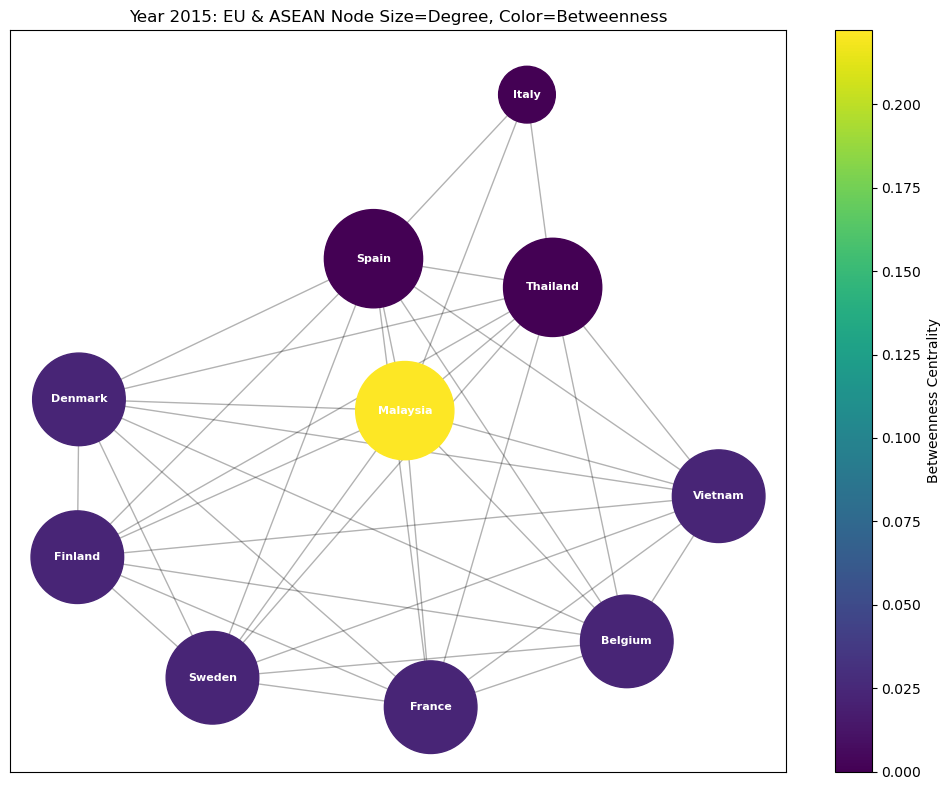


=== Year: 2015 ===
Top Degree Centrality:
   Year   Country  DegreeCentrality  BetweennessCentrality
1  2015  Thailand          1.000000               0.000000
2  2015     Spain          1.000000               0.000000
3  2015  Malaysia          1.000000               0.222222
4  2015   Vietnam          0.888889               0.023148
5  2015   Denmark          0.888889               0.023148
Top Betweenness Centrality:
   Year   Country  DegreeCentrality  BetweennessCentrality
3  2015  Malaysia          1.000000               0.222222
4  2015   Vietnam          0.888889               0.023148
5  2015   Denmark          0.888889               0.023148
6  2015   Belgium          0.888889               0.023148
7  2015    Sweden          0.888889               0.023148

Top 5 Strongest Connections (Edge weight):
Thailand - Spain: weight=10
Italy - Thailand: weight=9
Italy - Spain: weight=9
Thailand - Malaysia: weight=3
Spain - Malaysia: weight=3
GEXF file saved: gephi_files/network_2015

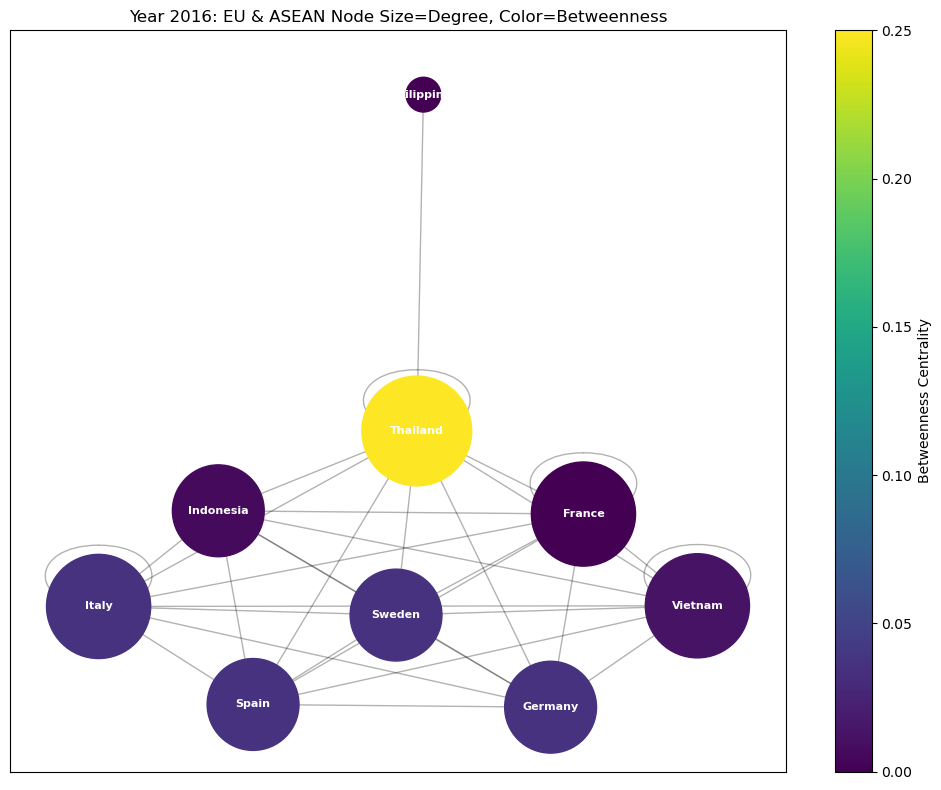


=== Year: 2016 ===
Top Degree Centrality:
   Year   Country  DegreeCentrality  BetweennessCentrality
0  2016  Thailand             1.250               0.250000
1  2016    France             1.125               0.000000
3  2016     Italy             1.125               0.035714
6  2016   Vietnam             1.125               0.011905
2  2016     Spain             0.875               0.035714
Top Betweenness Centrality:
   Year   Country  DegreeCentrality  BetweennessCentrality
0  2016  Thailand             1.250               0.250000
2  2016     Spain             0.875               0.035714
3  2016     Italy             1.125               0.035714
7  2016   Germany             0.875               0.035714
8  2016    Sweden             0.875               0.035714

Top 5 Strongest Connections (Edge weight):
Thailand - Thailand: weight=4
Thailand - France: weight=3
Thailand - Indonesia: weight=2
France - Vietnam: weight=2
Thailand - Spain: weight=1
GEXF file saved: gephi_files/netwo

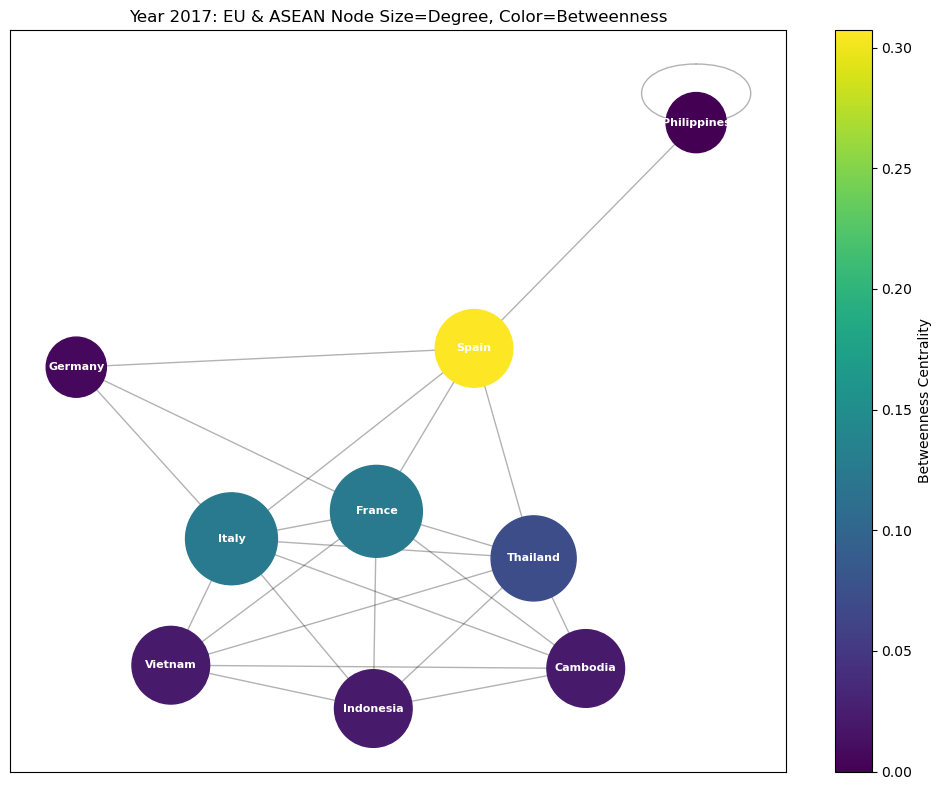


=== Year: 2017 ===
Top Degree Centrality:
   Year   Country  DegreeCentrality  BetweennessCentrality
3  2017     Italy             0.875               0.125000
4  2017    France             0.875               0.125000
2  2017  Thailand             0.750               0.071429
1  2017     Spain             0.625               0.307143
6  2017  Cambodia             0.625               0.021429
Top Betweenness Centrality:
   Year   Country  DegreeCentrality  BetweennessCentrality
1  2017     Spain             0.625               0.307143
3  2017     Italy             0.875               0.125000
4  2017    France             0.875               0.125000
2  2017  Thailand             0.750               0.071429
6  2017  Cambodia             0.625               0.021429

Top 5 Strongest Connections (Edge weight):
Italy - France: weight=3
Thailand - Italy: weight=2
Thailand - France: weight=2
Philippines - Spain: weight=1
Philippines - Philippines: weight=1
GEXF file saved: gephi_files/ne

/var/folders/s_/s1j9h97d2lb60zgcmh_ybvmc0000gn/T/ipykernel_79497/1004462793.py:40: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, alpha=0.3)


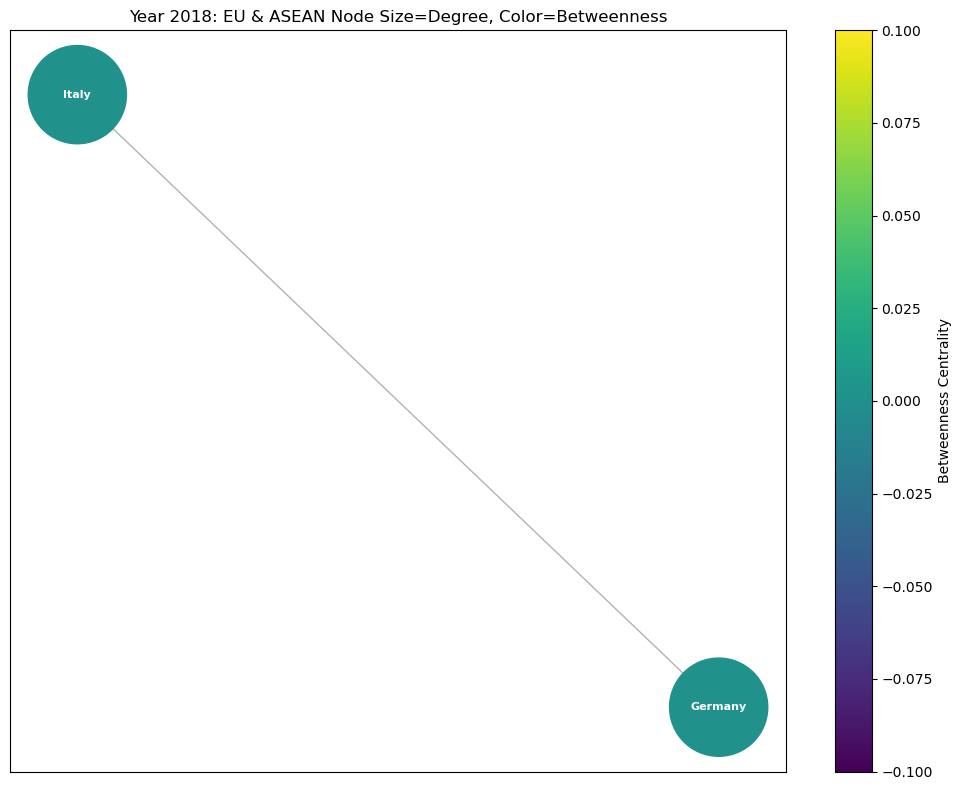


=== Year: 2018 ===
Top Degree Centrality:
   Year  Country  DegreeCentrality  BetweennessCentrality
0  2018    Italy               1.0                    0.0
1  2018  Germany               1.0                    0.0
Top Betweenness Centrality:
   Year  Country  DegreeCentrality  BetweennessCentrality
0  2018    Italy               1.0                    0.0
1  2018  Germany               1.0                    0.0

Top 5 Strongest Connections (Edge weight):
Italy - Germany: weight=1
GEXF file saved: gephi_files/network_2018_EU_ASEAN.gexf


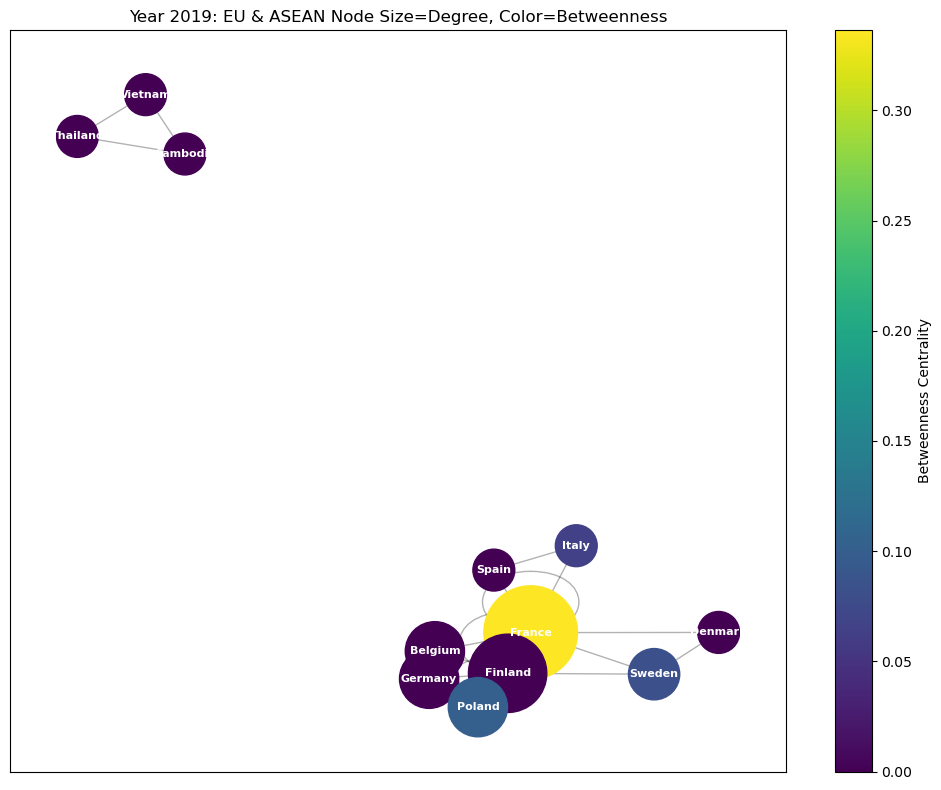


=== Year: 2019 ===
Top Degree Centrality:
   Year  Country  DegreeCentrality  BetweennessCentrality
1  2019   France          0.909091               0.336364
6  2019  Finland          0.636364               0.000000
7  2019  Germany          0.363636               0.000000
8  2019  Belgium          0.363636               0.000000
9  2019   Poland          0.363636               0.100000
Top Betweenness Centrality:
    Year Country  DegreeCentrality  BetweennessCentrality
1   2019  France          0.909091               0.336364
9   2019  Poland          0.363636               0.100000
10  2019  Sweden          0.272727               0.081818
0   2019   Italy          0.181818               0.063636
2   2019   Spain          0.181818               0.000000

Top 5 Strongest Connections (Edge weight):
Finland - Finland: weight=4
France - Finland: weight=3
France - France: weight=3
Finland - Germany: weight=3
Finland - Belgium: weight=3
GEXF file saved: gephi_files/network_2019_EU_ASEAN.g

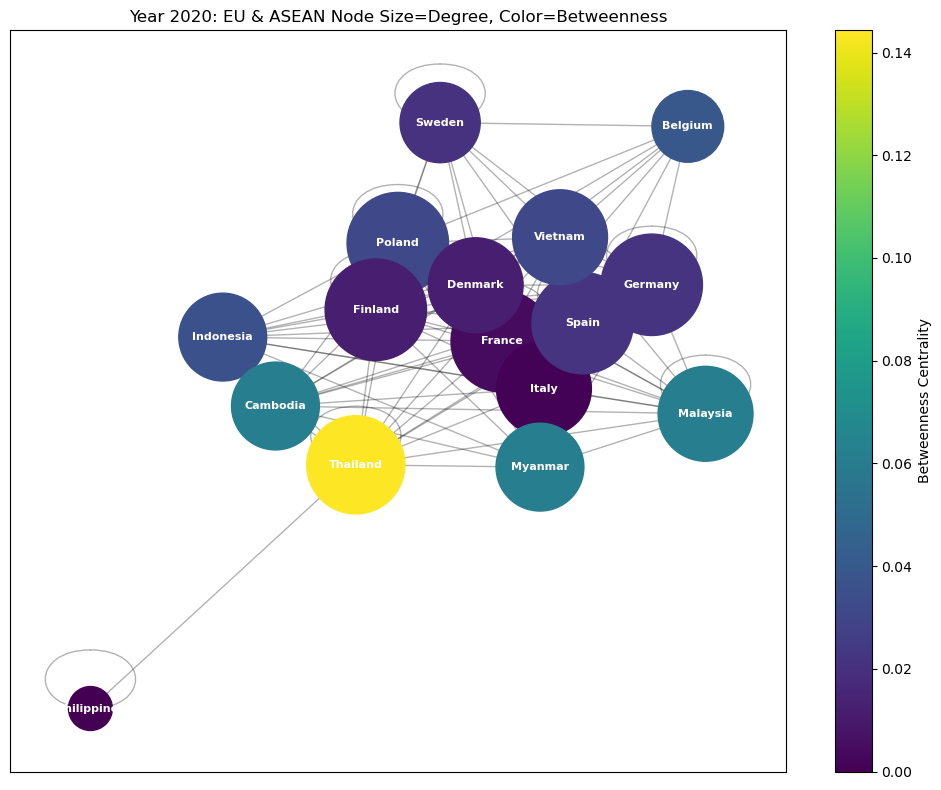


=== Year: 2020 ===
Top Degree Centrality:
   Year  Country  DegreeCentrality  BetweennessCentrality
0  2020  Germany          1.066667               0.021542
1  2020   France          1.066667               0.004082
3  2020   Poland          1.066667               0.031066
4  2020    Spain          1.066667               0.021542
5  2020  Finland          1.066667               0.012018
Top Betweenness Centrality:
    Year   Country  DegreeCentrality  BetweennessCentrality
8   2020  Thailand          1.000000               0.144324
10  2020  Malaysia          0.933333               0.061285
13  2020  Cambodia          0.800000               0.061285
14  2020   Myanmar          0.800000               0.061285
15  2020   Belgium          0.533333               0.038904

Top 5 Strongest Connections (Edge weight):
France - Spain: weight=38
France - Italy: weight=36
France - France: weight=7
Spain - Spain: weight=7
France - Finland: weight=5
GEXF file saved: gephi_files/network_2020_EU_ASE

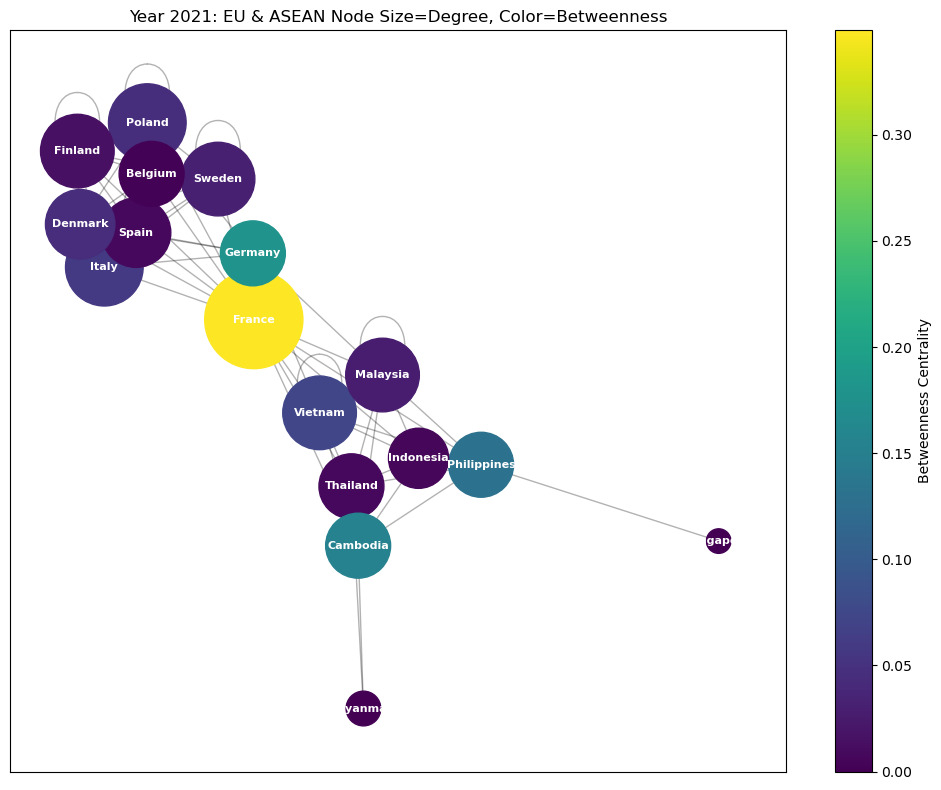


=== Year: 2021 ===
Top Degree Centrality:
    Year  Country  DegreeCentrality  BetweennessCentrality
1   2021   France            1.0000               0.349255
0   2021    Italy            0.6250               0.057828
5   2021   Poland            0.6250               0.045606
11  2021  Vietnam            0.5625               0.073662
15  2021   Sweden            0.5625               0.030833
Top Betweenness Centrality:
    Year      Country  DegreeCentrality  BetweennessCentrality
1   2021       France            1.0000               0.349255
4   2021      Germany            0.4375               0.179217
9   2021     Cambodia            0.4375               0.154003
6   2021  Philippines            0.4375               0.131111
11  2021      Vietnam            0.5625               0.073662

Top 5 Strongest Connections (Edge weight):
Italy - Spain: weight=13
Italy - Denmark: weight=8
Spain - Denmark: weight=8
France - Sweden: weight=3
Poland - Finland: weight=3
GEXF file saved: gephi_

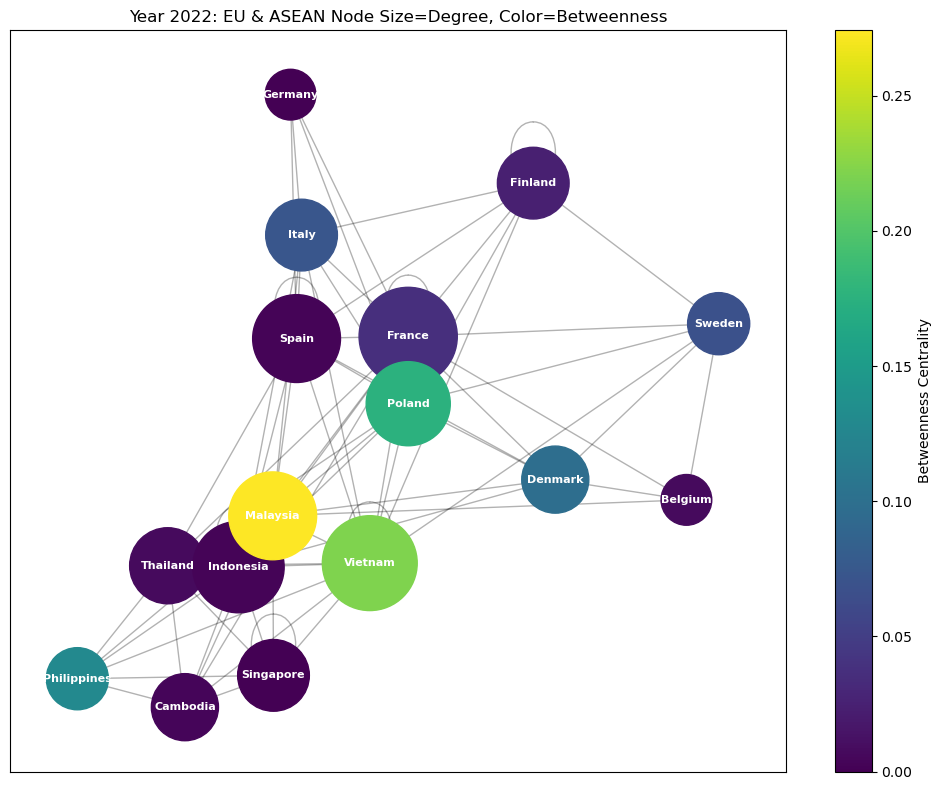


=== Year: 2022 ===
Top Degree Centrality:
    Year    Country  DegreeCentrality  BetweennessCentrality
1   2022     France          1.000000               0.036667
9   2022    Vietnam          0.933333               0.221633
8   2022  Indonesia          0.866667               0.003175
3   2022      Spain          0.800000               0.003175
10  2022   Malaysia          0.800000               0.274218
Top Betweenness Centrality:
    Year      Country  DegreeCentrality  BetweennessCentrality
10  2022     Malaysia          0.800000               0.274218
9   2022      Vietnam          0.933333               0.221633
4   2022       Poland          0.733333               0.175556
11  2022  Philippines          0.400000               0.128571
15  2022      Denmark          0.466667               0.098345

Top 5 Strongest Connections (Edge weight):
Thailand - Indonesia: weight=14
Thailand - Malaysia: weight=10
Singapore - Indonesia: weight=9
Italy - France: weight=8
Thailand - Singapore:

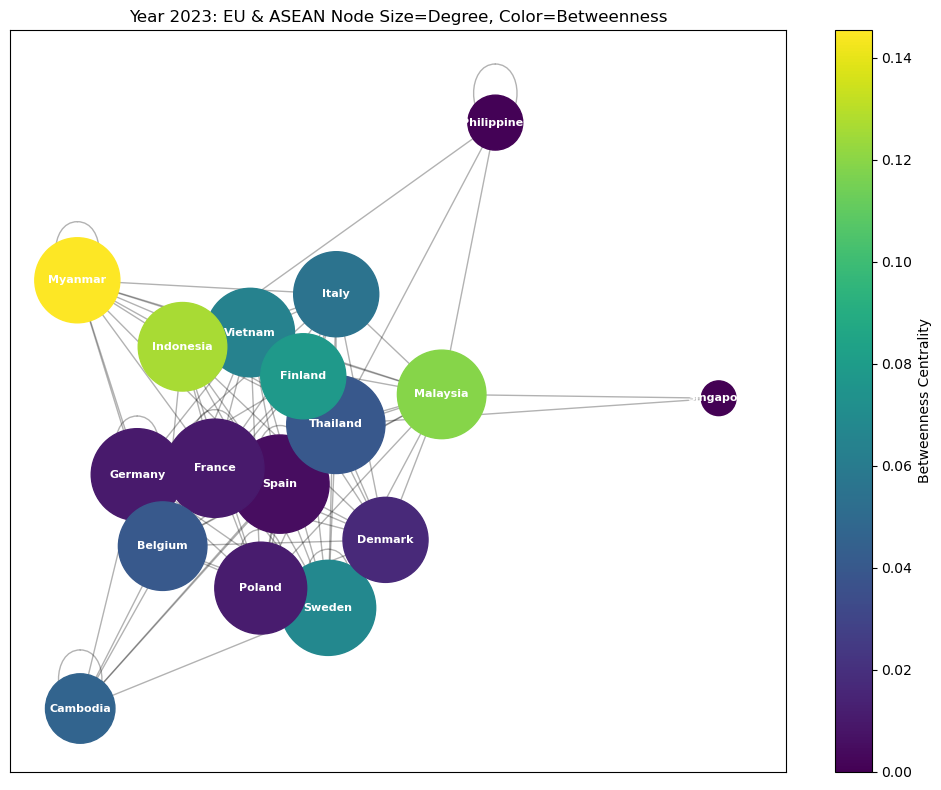


=== Year: 2023 ===
Top Degree Centrality:
    Year   Country  DegreeCentrality  BetweennessCentrality
0   2023     Spain            1.0000               0.004861
2   2023    France            1.0000               0.009802
3   2023  Thailand            1.0000               0.039444
12  2023    Sweden            0.9375               0.068095
14  2023    Poland            0.8750               0.010913
Top Betweenness Centrality:
    Year    Country  DegreeCentrality  BetweennessCentrality
16  2023    Myanmar            0.7500               0.145337
10  2023  Indonesia            0.8125               0.126052
6   2023   Malaysia            0.8125               0.118800
15  2023    Finland            0.7500               0.077887
12  2023     Sweden            0.9375               0.068095

Top 5 Strongest Connections (Edge weight):
Thailand - Vietnam: weight=18
France - France: weight=16
Spain - France: weight=10
France - Thailand: weight=10
Spain - Thailand: weight=7
GEXF file saved: gep

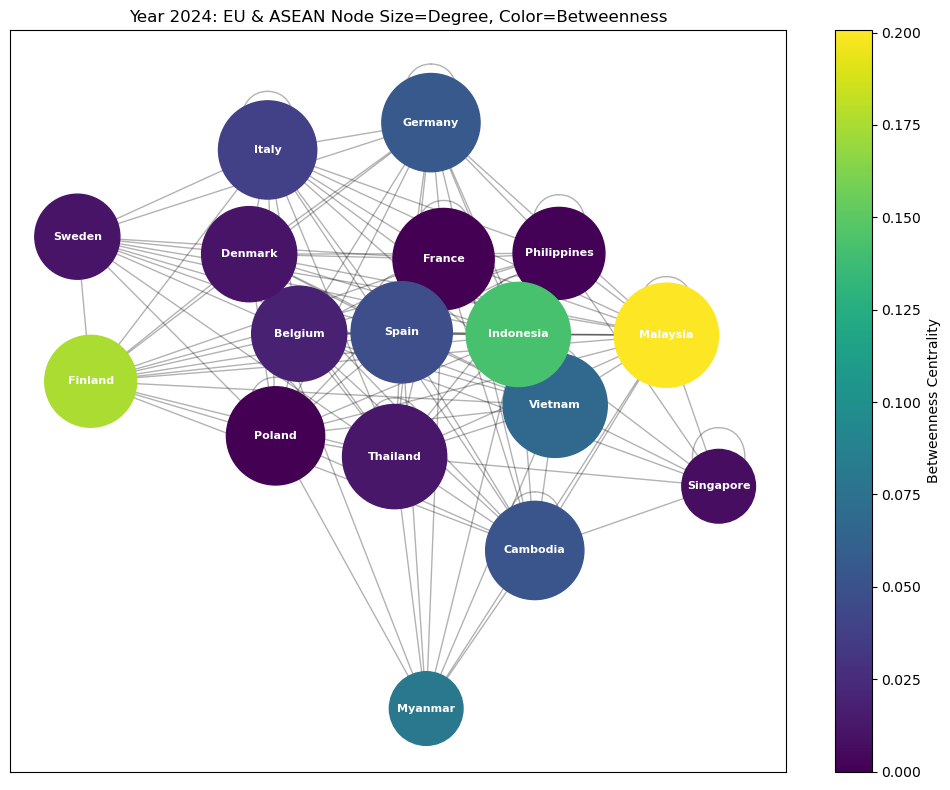


=== Year: 2024 ===
Top Degree Centrality:
    Year    Country  DegreeCentrality  BetweennessCentrality
6   2024    Vietnam            1.1250               0.066796
1   2024   Malaysia            1.1250               0.200605
10  2024  Indonesia            1.1250               0.142609
11  2024   Thailand            1.1250               0.011756
5   2024     France            1.0625               0.000000
Top Betweenness Centrality:
    Year    Country  DegreeCentrality  BetweennessCentrality
1   2024   Malaysia            1.1250               0.200605
13  2024    Finland            0.8750               0.174881
10  2024  Indonesia            1.1250               0.142609
15  2024    Myanmar            0.5625               0.080159
6   2024    Vietnam            1.1250               0.066796

Top 5 Strongest Connections (Edge weight):
France - France: weight=36
Philippines - Vietnam: weight=30
Vietnam - Singapore: weight=30
France - Spain: weight=27
Philippines - Indonesia: weight=26
G

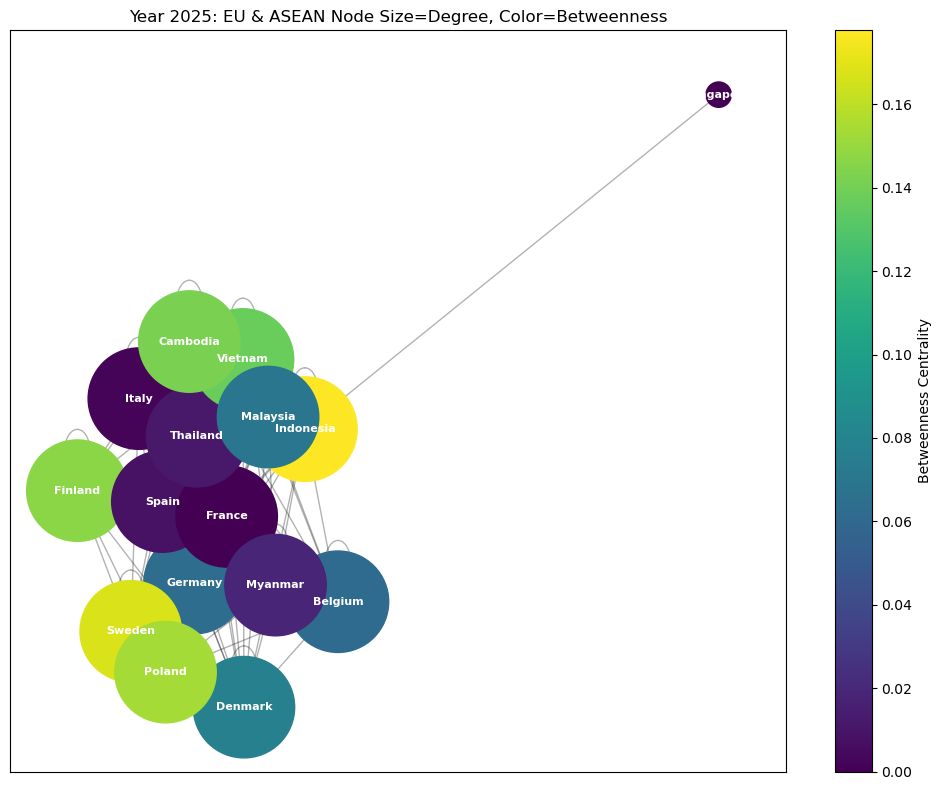


=== Year: 2025 ===
Top Degree Centrality:
   Year    Country  DegreeCentrality  BetweennessCentrality
0  2025  Indonesia          1.133333               0.177778
2  2025    Germany          1.066667               0.062698
3  2025    Finland          1.066667               0.146825
4  2025     Sweden          1.066667               0.167381
5  2025      Spain          1.066667               0.007937
Top Betweenness Centrality:
    Year    Country  DegreeCentrality  BetweennessCentrality
0   2025  Indonesia          1.133333               0.177778
4   2025     Sweden          1.066667               0.167381
14  2025     Poland          1.066667               0.153889
3   2025    Finland          1.066667               0.146825
15  2025   Cambodia          1.066667               0.141905

Top 5 Strongest Connections (Edge weight):
Spain - France: weight=121
France - France: weight=106
Germany - France: weight=67
Spain - Spain: weight=57
France - Vietnam: weight=56
GEXF file saved: gephi_

In [13]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

# 🔍 관심 있는 국가 리스트 (EU + ASEAN)
eu_asean_countries = [
    'France', 'Germany', 'Sweden', 'Belgium', 'Denmark', 'Poland', 'Finland', 'Italy', 'Spain',
    'Thailand', 'Vietnam', 'Indonesia', 'Malaysia', 'Singapore', 'Cambodia', 'Philippines', 'Myanmar'
]

# 📁 GEXF 파일 저장 폴더 생성
os.makedirs('gephi_files', exist_ok=True)

for year, counts in pairs_per_year.items():
    G = nx.Graph()
    for (c1, c2), weight in counts.items():
        # 🚨 EU + ASEAN 국가만 포함하도록 필터링
        if c1 in eu_asean_countries and c2 in eu_asean_countries:
            G.add_edge(c1, c2, weight=weight)

    if len(G.nodes()) == 0:
        print(f"\n=== Year: {year} ===\nNo EU/ASEAN nodes to visualize.")
        continue

    # 🌟 중심성 계산
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

    # 🎨 노드 속성 추가
    nx.set_node_attributes(G, degree_centrality, 'degree_centrality')
    nx.set_node_attributes(G, betweenness_centrality, 'betweenness_centrality')

    pos = nx.spring_layout(G, seed=42)
    node_size = [5000 * degree_centrality[n] for n in G.nodes()]
    node_color = [betweenness_centrality[n] for n in G.nodes()]

    plt.figure(figsize=(10, 8))
    nodes = nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_color, cmap=plt.cm.viridis)
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold')
    plt.title(f"Year {year}: EU & ASEAN Node Size=Degree, Color=Betweenness")
    plt.colorbar(nodes, label='Betweenness Centrality')
    plt.tight_layout()
    plt.savefig(f'centrality_visualization_{year}_EU_ASEAN.png', dpi=300)
    plt.show()

    # 💡 중심성 상위 출력
    top_degree = pd.DataFrame({
        'Year': year,
        'Country': list(degree_centrality.keys()),
        'DegreeCentrality': list(degree_centrality.values()),
        'BetweennessCentrality': [betweenness_centrality[n] for n in G.nodes()]
    }).sort_values(by='DegreeCentrality', ascending=False).head(5)

    top_betweenness = pd.DataFrame({
        'Year': year,
        'Country': list(betweenness_centrality.keys()),
        'DegreeCentrality': list(degree_centrality.values()),
        'BetweennessCentrality': [betweenness_centrality[n] for n in G.nodes()]
    }).sort_values(by='BetweennessCentrality', ascending=False).head(5)

    print(f"\n=== Year: {year} ===")
    print("Top Degree Centrality:")
    print(top_degree)
    print("Top Betweenness Centrality:")
    print(top_betweenness)

    # 🌐 강한 연결 출력 (Edge weight)
    top_edges = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
    print("\nTop 5 Strongest Connections (Edge weight):")
    for u, v, data in top_edges:
        print(f"{u} - {v}: weight={data['weight']}")

    # 📁 GEXF 파일 저장
    gexf_filename = f'gephi_files/network_{year}_EU_ASEAN.gexf'
    nx.write_gexf(G, gexf_filename)
    print(f"GEXF file saved: {gexf_filename}")


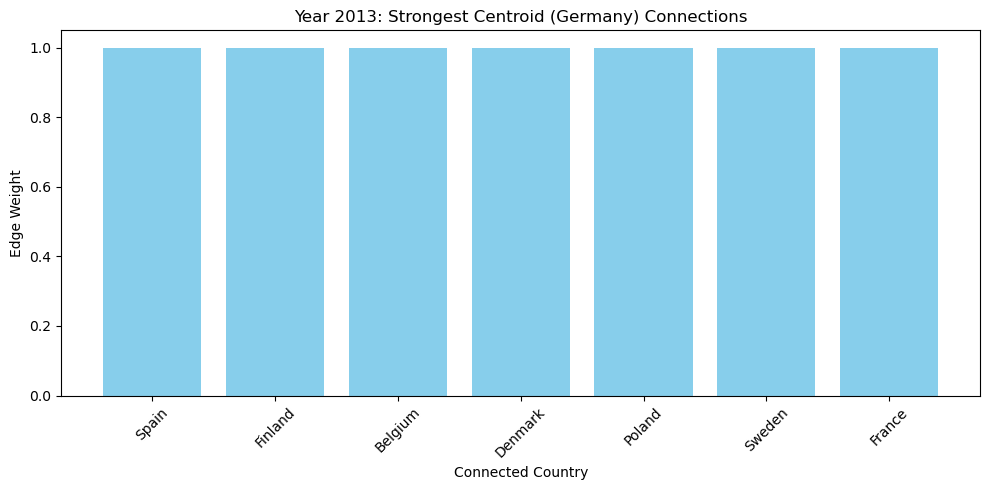

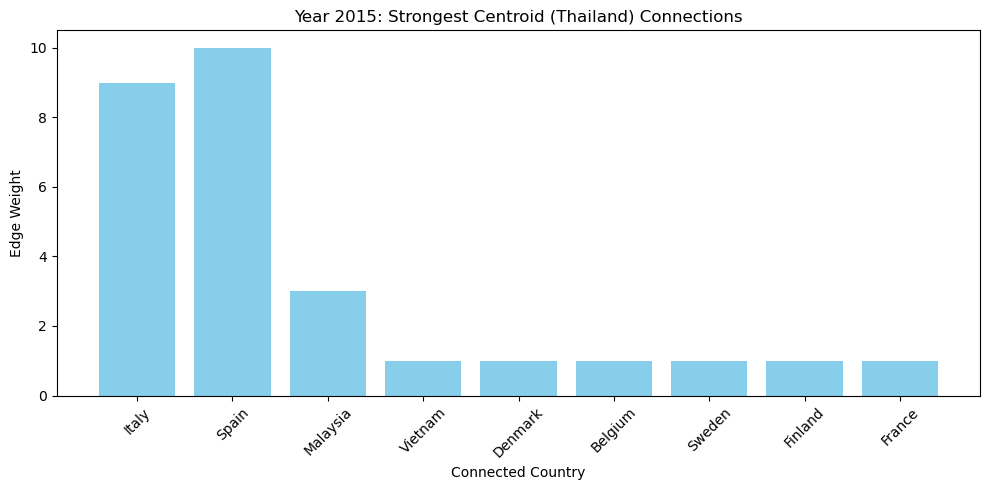

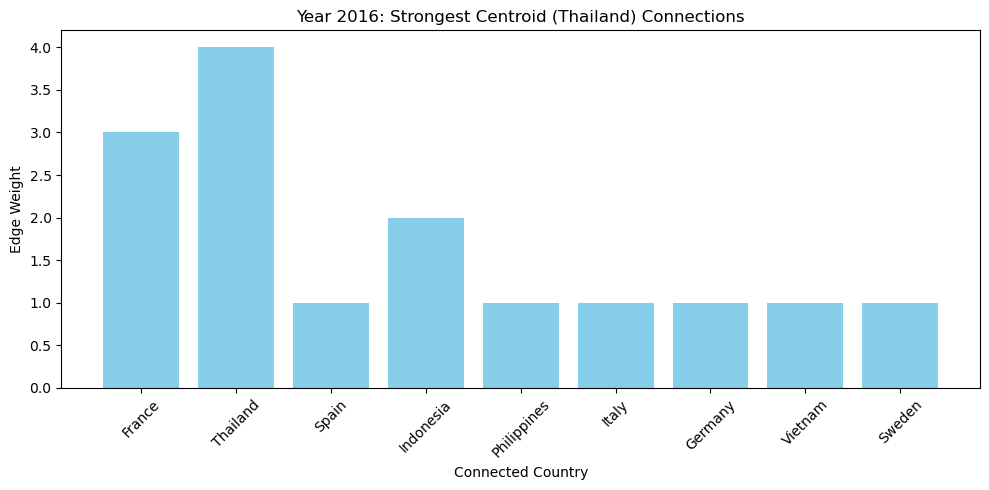

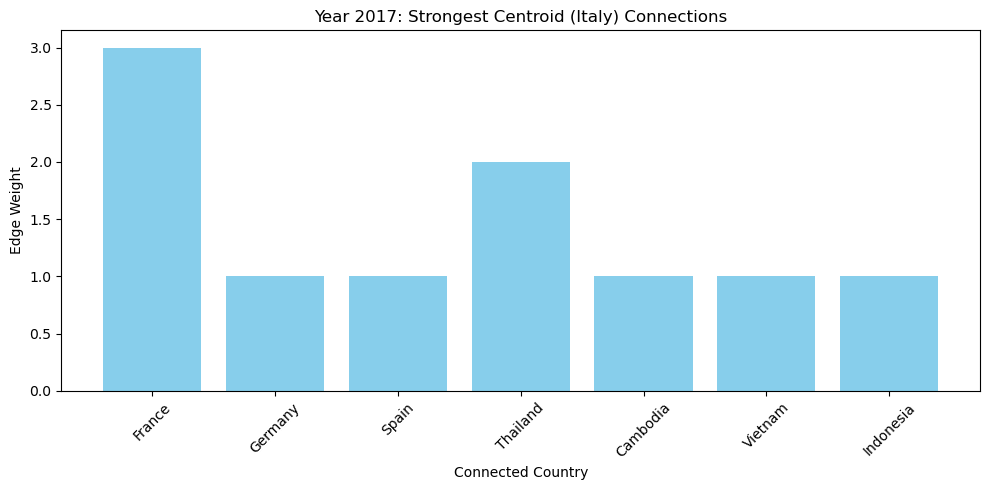

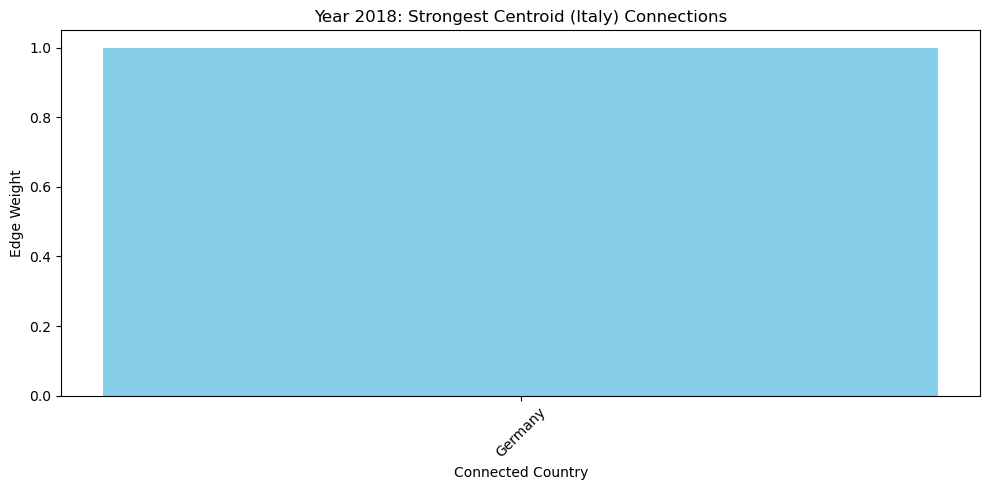

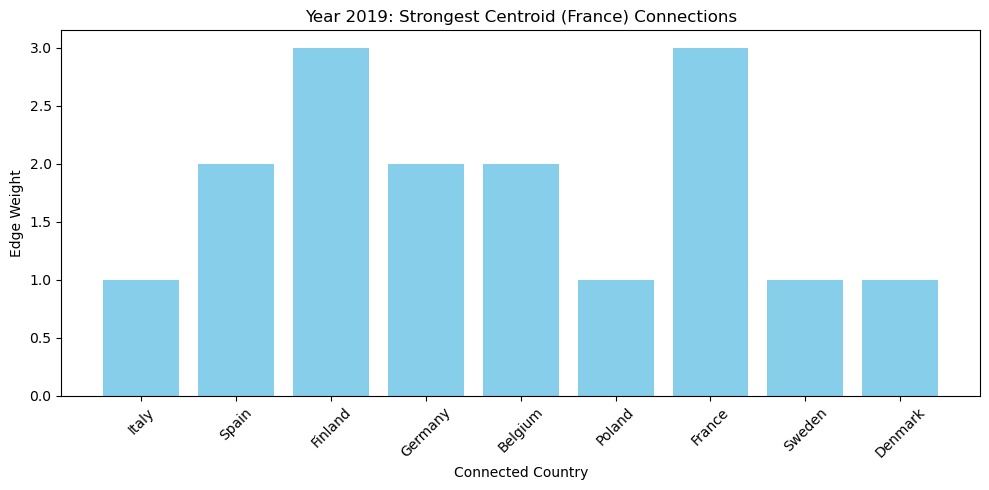

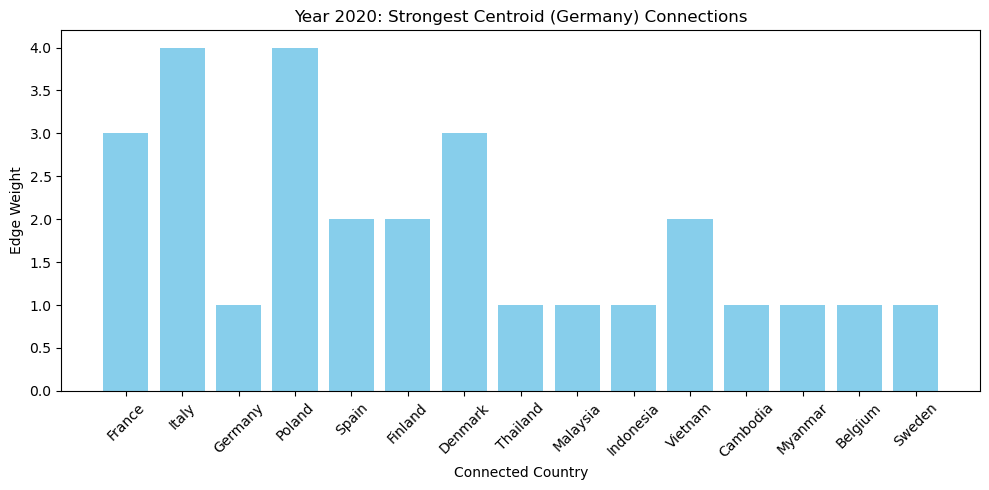

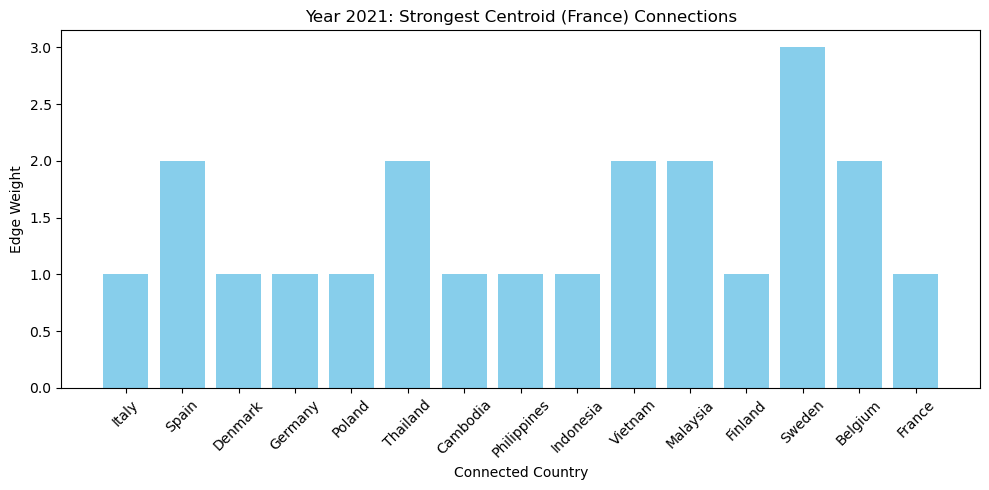

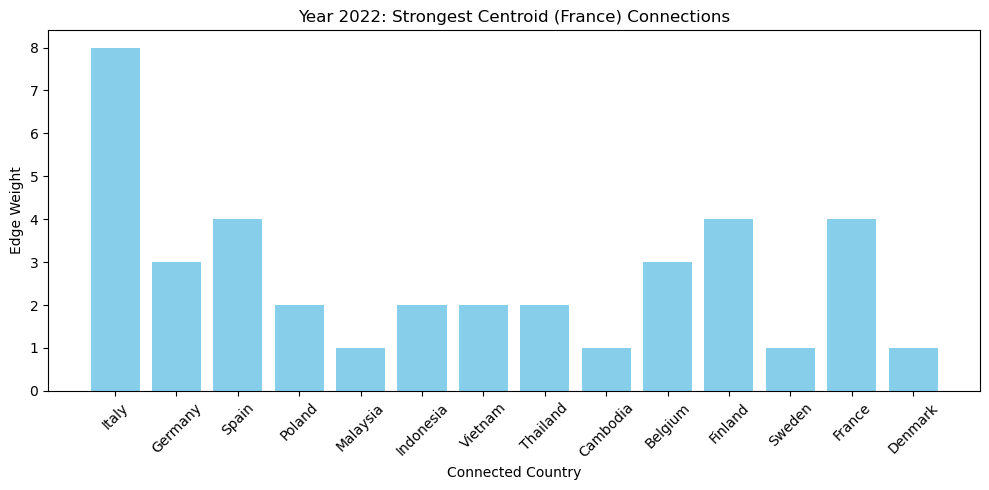

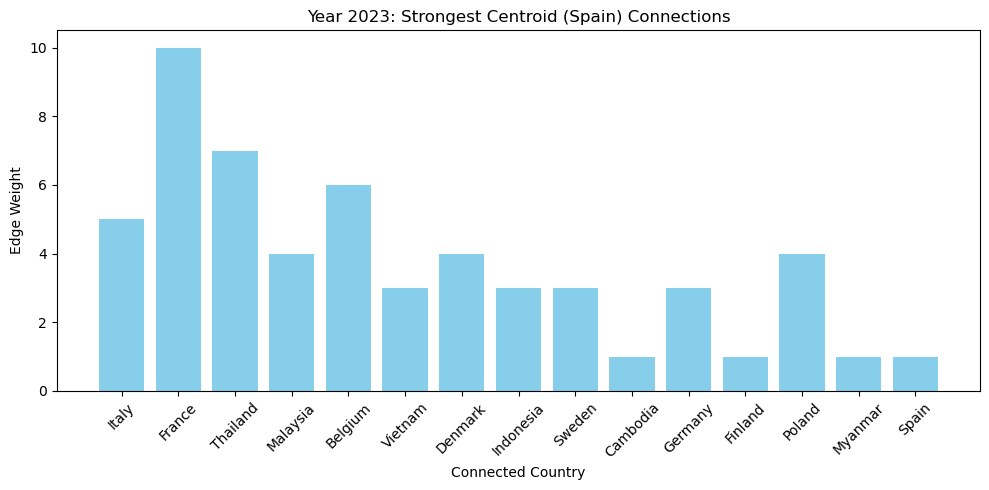

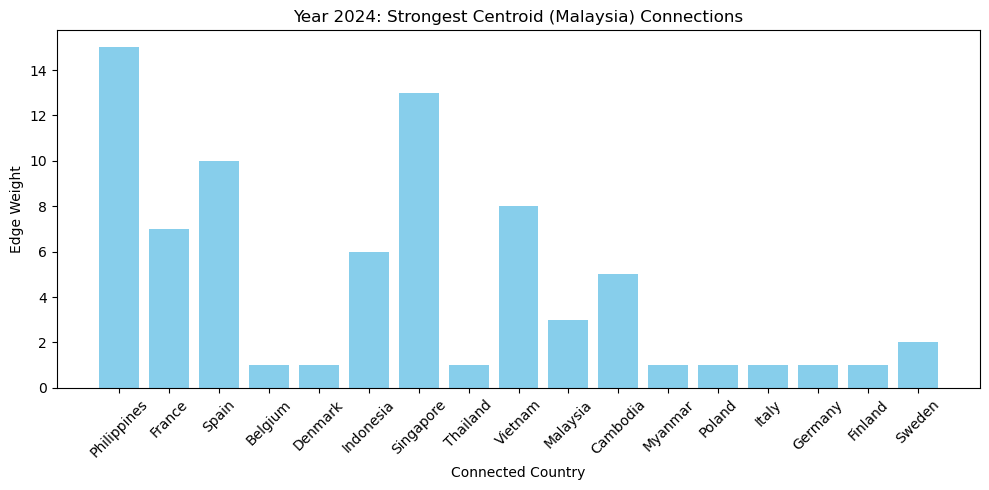

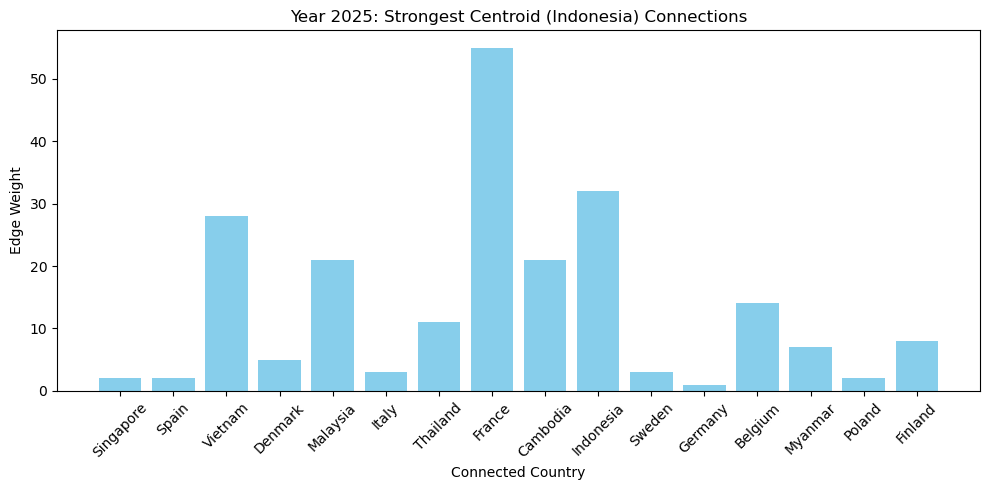

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔍 EU+ASEAN 국가 리스트 (위 코드와 일치)
eu_asean_countries = [
    'France', 'Germany', 'Sweden', 'Belgium', 'Denmark', 'Poland', 'Finland', 'Italy', 'Spain',
    'Thailand', 'Vietnam', 'Indonesia', 'Malaysia', 'Singapore', 'Cambodia', 'Philippines', 'Myanmar'
]

for year, counts in pairs_per_year.items():
    G = nx.Graph()
    for (c1, c2), weight in counts.items():
        if c1 in eu_asean_countries and c2 in eu_asean_countries:
            G.add_edge(c1, c2, weight=weight)
    
    if len(G.nodes()) == 0:
        print(f"\n=== Year: {year} ===\nNo EU/ASEAN nodes.")
        continue

    # 🌟 Degree 중심성 계산 및 가장 높은 노드(centroid) 선택
    degree_centrality = nx.degree_centrality(G)
    centroid_country = max(degree_centrality, key=degree_centrality.get)

    # 해당 centroid 노드와 연결된 국가 및 가중치 추출
    neighbors = list(G.neighbors(centroid_country))
    weights = [G[centroid_country][neighbor]['weight'] for neighbor in neighbors]
    
    if not neighbors:
        print(f"\n=== Year: {year} ===\nNo connections for centroid {centroid_country}.")
        continue

    # 막대그래프 그리기
    plt.figure(figsize=(10, 5))
    plt.bar(neighbors, weights, color='skyblue')
    plt.xlabel('Connected Country')
    plt.ylabel('Edge Weight')
    plt.title(f'Year {year}: Strongest Centroid ({centroid_country}) Connections')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
